In [12]:

# SECTION 0: IMPORTS & CONFIGURATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

from pathlib import Path
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu

warnings.filterwarnings("ignore")

# ── Global Plot Style ──────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
})

# Color palette — binary focus first
PALETTE_BINARY = {0: "#2ecc71", 1: "#e74c3c"}
LABEL_MAP      = {0: "Low Risk", 1: "High Risk"}
COLORS         = ["#2ecc71", "#e74c3c"]

# Paths
PROJECT_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd().resolve()
)
DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "synthetic_gambling_data.csv"
FIGURES_DIR  = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Imports complete")
print(f"Figures → {FIGURES_DIR}")

Imports complete
Figures → /Users/tsing/May02_Gamble/Gambling-ML-/figures


In [13]:
# SECTION 1: LOAD RAW DATA
df_raw = pd.read_csv(DATASET_PATH)
df_raw.info()
df_raw.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 56 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   player_id                            6000 non-null   int64  
 1   signup_date                          6000 non-null   object 
 2   age                                  5705 non-null   float64
 3   primary_product_type                 6000 non-null   object 
 4   synthetic_income_monthly             5677 non-null   float64
 5   debt_to_income_ratio                 5682 non-null   float64
 6   synthetic_credit_score               5712 non-null   float64
 7   risk_profile                         6000 non-null   int64  
 8   data_year                            6000 non-null   int64  
 9   account_tenure_days                  5692 non-null   float64
 10  credit_score_velocity_7d             5690 non-null   float64
 11  liquid_savings_balance        

,player_id,age,synthetic_income_monthly,debt_to_income_ratio,synthetic_credit_score,risk_profile,data_year,account_tenure_days,credit_score_velocity_7d,liquid_savings_balance,...,bonus_sensitivity_index,push_notification_density,gambling_ad_ctr,vip_status,limit_setting_flag,deposit_limit_breach_attempts,time_out_requests_count,responsible_gambling_message_count,regulatory_friction_score,friction_bypass_attempt_flag
count,6000.00000,5705.000000,5677.000000,5682.000000,5712.000000,6000.000000,6000.000000,5692.000000,5690.000000,5691.000000,...,5701.000000,5694.000000,5718.000000,5719.000000,5723.000000,5696.000000,5708.000000,5710.000000,5715.000000,5702.000000
mean,100499.50000,43.291849,4850.014522,0.746258,568.164741,0.500000,2022.500000,1640.977161,-10.669420,23831.944041,...,0.510768,24.363014,0.503135,0.101941,0.493622,2.531777,0.983006,9.578984,0.499571,0.050333
std,288.69905,15.184577,1977.234704,0.436662,156.575014,0.670876,1.707967,658.888002,11.525429,13867.526467,...,0.288512,14.301333,0.288706,0.302597,0.500003,1.713257,0.990878,5.781172,0.289300,0.218651
min,100000.00000,18.000000,1000.000000,0.000963,300.000000,0.000000,2020.000000,366.000000,-30.000000,3.196259,...,0.000092,0.000000,0.000231,0.000000,0.000000,0.000000,0.000000,0.000000,0.000043,0.000000
25%,100249.75000,30.000000,3479.619823,0.367282,433.000000,0.000000,2021.000000,1091.000000,-21.000000,11989.995502,...,0.262697,12.000000,0.254519,0.000000,0.000000,1.000000,0.000000,5.000000,0.247375,0.000000
50%,100499.50000,43.000000,4935.325763,0.759710,565.000000,0.000000,2022.500000,1639.500000,-11.000000,23839.499501,...,0.510742,24.000000,0.500007,0.000000,0.000000,2.000000,1.000000,10.000000,0.503060,0.000000
75%,100749.25000,57.000000,6177.406556,1.118513,702.000000,1.000000,2024.000000,2189.500000,-1.000000,35555.884651,...,0.768956,37.000000,0.755075,0.000000,1.000000,3.000000,2.000000,15.000000,0.748877,0.000000
max,100999.00000,76.000000,10828.489297,1.499113,849.000000,2.000000,2025.000000,2918.000000,9.000000,49997.070504,...,0.999994,49.000000,0.999960,1.000000,1.000000,11.000000,8.000000,19.000000,0.999737,1.000000


In [14]:
missing_summary = (
    df_raw.isna()
      .sum()
      .sort_values(ascending=False)
      .rename("missing_count")
      .to_frame()
)
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(df_raw) * 100).round(2)
missing_summary

,missing_count,missing_pct
bonus_redemption_rate,337,5.62
failed_deposit_count_30d,335,5.58
deposit_growth_rate_4w,332,5.53
max_bet_size,329,5.48
synthetic_income_monthly,323,5.38
avg_bet_size,319,5.32
debt_to_income_ratio,318,5.30
avg_session_duration_minutes,315,5.25
rapid_redeposit_rate,312,5.20
total_bets_30d,312,5.20


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

# Load & Setup
df_raw = pd.read_csv(DATASET_PATH)
TARGET = "risk_profile"
ID_DATE_META = ["player_id", "data_year", "signup_date"]
CAT_COLS = [
    "primary_product_type", "affiliate_referral_source",
    "vip_status", "limit_setting_flag", "same_day_multiple_session_flag", 
    "friction_bypass_attempt_flag"
]
NUM_COLS = [c for c in df_raw.columns if c not in CAT_COLS + ID_DATE_META + [TARGET]]
LABEL_MAP = {0: "Low", 1: "Medium", 2: "High"}
COLORS = ["#2ecc71", "#f39c12", "#e74c3c"]

print(f"📊 Loaded: {len(df_raw):,} rows × {len(df_raw.columns)} cols")

📊 Loaded: 6,000 rows × 56 cols


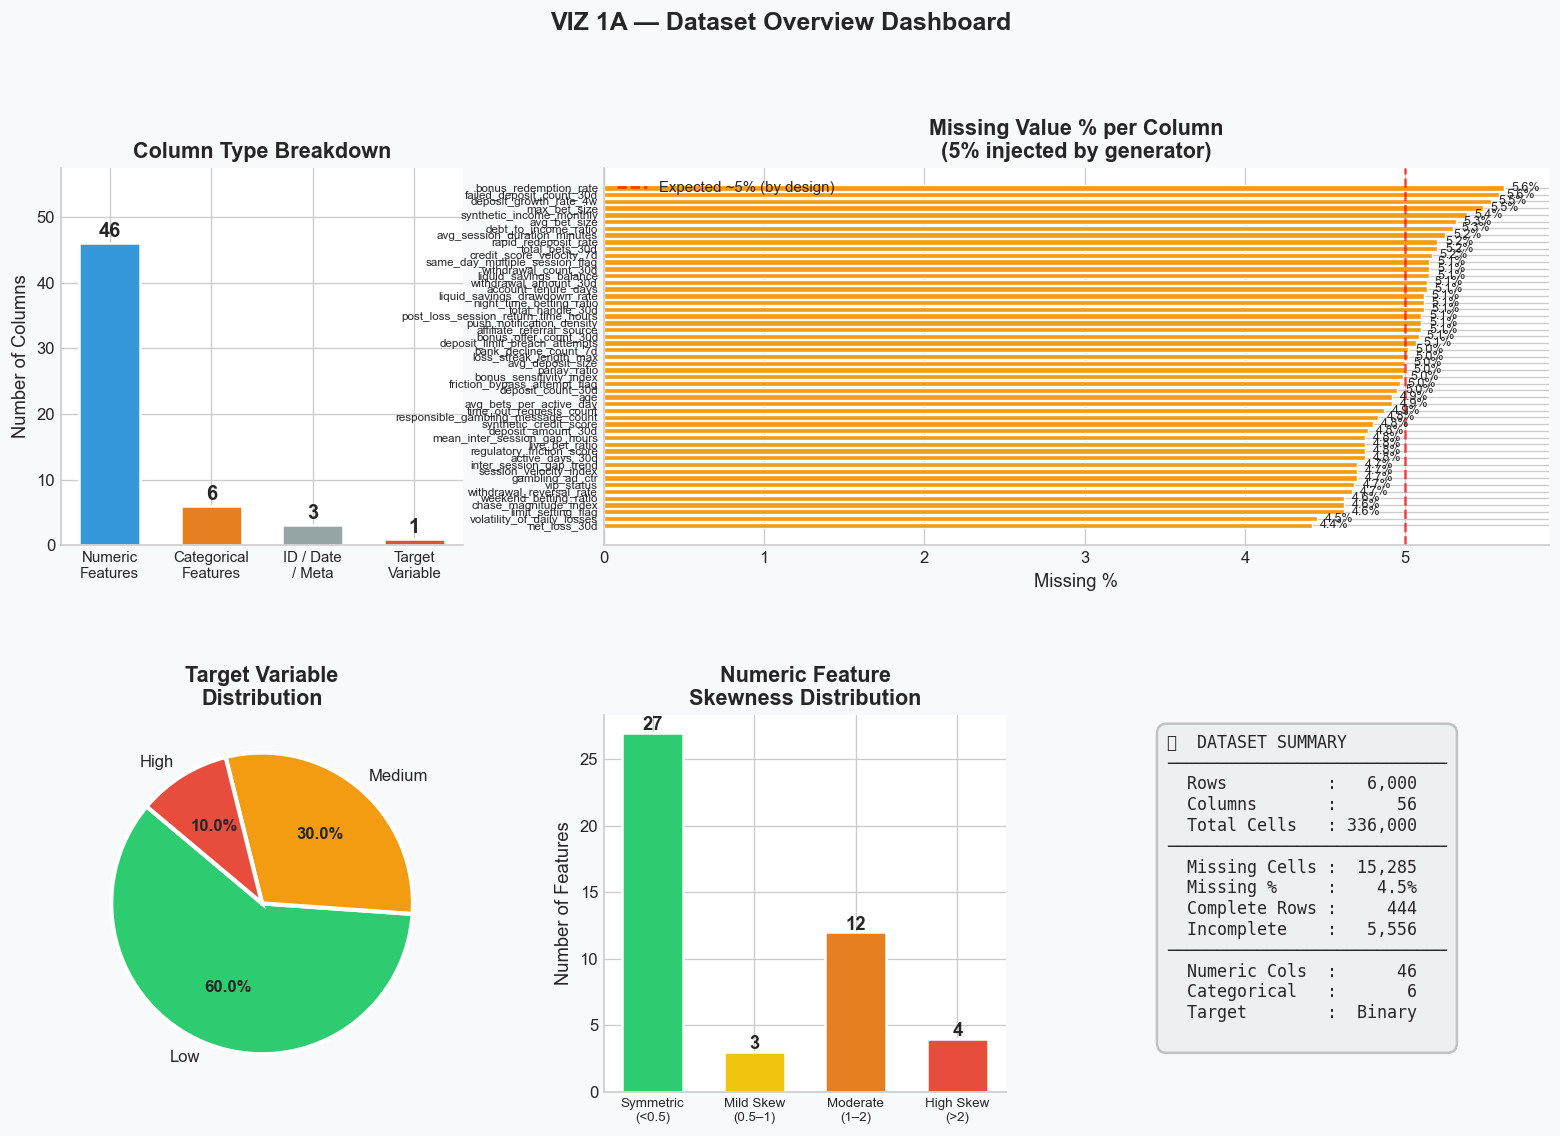

✅ VIZ 1A saved


In [17]:

# VIZ 1A: Dataset Overview Dashboard

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#f8f9fa")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Column type breakdown ────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

CAT_COLS = [
    "primary_product_type", "affiliate_referral_source",
    "vip_status", "limit_setting_flag",
    "same_day_multiple_session_flag", "friction_bypass_attempt_flag",
]

# Define the target variable
TARGET = "risk_profile"


NUM_COLS = [
    c for c in df_raw.columns
    if c not in CAT_COLS + ID_DATE_META + [TARGET]
]

type_counts = {
    "Numeric\nFeatures"      : len(NUM_COLS),
    "Categorical\nFeatures"  : len(CAT_COLS),
    "ID / Date\n/ Meta"      : len(ID_DATE_META),
    "Target\nVariable"       : 1,
}
bar_colors = ["#3498db", "#e67e22", "#95a5a6", "#e74c3c"]
bars = ax1.bar(
    type_counts.keys(), type_counts.values(),
    color=bar_colors, edgecolor="white", linewidth=1.5, width=0.6
)
for bar, val in zip(bars, type_counts.values()):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(val), ha="center", va="bottom",
        fontsize=12, fontweight="bold"
    )
ax1.set_title("Column Type Breakdown")
ax1.set_ylabel("Number of Columns")
ax1.set_ylim(0, max(type_counts.values()) * 1.25)
ax1.tick_params(axis="x", labelsize=9)

# ── Panel 2: Missing values per column ────────────────────
ax2 = fig.add_subplot(gs[0, 1:])

missing = df_raw.isna().sum()
missing = missing[missing > 0].sort_values(ascending=True)
missing_pct = (missing / len(df_raw) * 100)

colors_miss = [
    "#e74c3c" if p > 7 else "#f39c12" if p > 4 else "#2ecc71"
    for p in missing_pct
]
bars2 = ax2.barh(
    missing.index, missing_pct.values,
    color=colors_miss, edgecolor="white", linewidth=0.8
)
for bar, val in zip(bars2, missing_pct.values):
    ax2.text(
        val + 0.05, bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%", va="center", fontsize=7.5
    )
ax2.axvline(5, color="red", linestyle="--", linewidth=1.5,
            alpha=0.7, label="Expected ~5% (by design)")
ax2.set_title("Missing Value % per Column\n(5% injected by generator)")
ax2.set_xlabel("Missing %")
ax2.legend(fontsize=9)
ax2.tick_params(axis="y", labelsize=7)

# ── Panel 3: Target distribution ──────────────────────────
ax3 = fig.add_subplot(gs[1, 0])

target_counts = df_raw[TARGET].value_counts().sort_index()
wedges, texts, autotexts = ax3.pie(
    target_counts.values,
    labels=[LABEL_MAP[i] for i in target_counts.index],
    colors=COLORS,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2.5},
    textprops={"fontsize": 10},
)
for at in autotexts:
    at.set_fontweight("bold")
ax3.set_title("Target Variable\nDistribution")

# ── Panel 4: Numeric column stats summary ─────────────────
ax4 = fig.add_subplot(gs[1, 1])

skewness = df_raw[NUM_COLS].skew().abs()
skew_bins = pd.cut(
    skewness,
    bins=[-np.inf, 0.5, 1.0, 2.0, np.inf],
    labels=["Symmetric\n(<0.5)", "Mild Skew\n(0.5–1)", 
            "Moderate\n(1–2)", "High Skew\n(>2)"]
)
skew_counts = skew_bins.value_counts().sort_index()
ax4.bar(
    skew_counts.index, skew_counts.values,
    color=["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"],
    edgecolor="white", linewidth=1.5, width=0.6
)
for i, val in enumerate(skew_counts.values):
    ax4.text(i, val + 0.2, str(val), ha="center",
             fontsize=11, fontweight="bold")
ax4.set_title("Numeric Feature\nSkewness Distribution")
ax4.set_ylabel("Number of Features")
ax4.tick_params(axis="x", labelsize=8)

# ── Panel 5: Dataset size summary text ────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis("off")

total_cells  = df_raw.shape[0] * df_raw.shape[1]
missing_cells= df_raw.isna().sum().sum()
complete_rows= df_raw.dropna().shape[0]

summary_text = (
    f"📊  DATASET SUMMARY\n"
    f"{'─'*28}\n"
    f"  Rows          : {df_raw.shape[0]:>7,}\n"
    f"  Columns       : {df_raw.shape[1]:>7,}\n"
    f"  Total Cells   : {total_cells:>7,}\n"
    f"{'─'*28}\n"
    f"  Missing Cells : {missing_cells:>7,}\n"
    f"  Missing %     : {missing_cells/total_cells*100:>6.1f}%\n"
    f"  Complete Rows : {complete_rows:>7,}\n"
    f"  Incomplete    : {df_raw.shape[0]-complete_rows:>7,}\n"
    f"{'─'*28}\n"
    f"  Numeric Cols  : {len(NUM_COLS):>7,}\n"
    f"  Categorical   : {len(CAT_COLS):>7,}\n"
    f"  Target        : {'Binary':>7}\n"
)
ax5.text(
    0.05, 0.95, summary_text,
    transform=ax5.transAxes,
    fontsize=10, verticalalignment="top",
    fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#ecf0f1",
              edgecolor="#bdc3c7", linewidth=1.5)
)

plt.suptitle(
    "VIZ 1A — Dataset Overview Dashboard",
    fontsize=15, fontweight="bold", y=1.01
)
plt.savefig(FIGURES_DIR / "VIZ_1A_dataset_overview.png", bbox_inches="tight")
plt.show()
print("✅ VIZ 1A saved")

BEGIN CLEANING 



In [18]:

#Missing value 

print("\n STEP 1: IMPUTATION")
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')

df_clean = df_raw.copy()
df_clean[NUM_COLS] = pd.DataFrame(
    imputer_num.fit_transform(df_clean[NUM_COLS]), columns=NUM_COLS, index=df_clean.index
)
df_clean[CAT_COLS] = pd.DataFrame(
    imputer_cat.fit_transform(df_clean[CAT_COLS]), columns=CAT_COLS, index=df_clean.index
)
print(f"Missing values: {df_clean[NUM_COLS].isna().sum().sum()} (was {df_raw[NUM_COLS].isna().sum().sum()})")



 STEP 1: IMPUTATION
Missing values: 0 (was 13814)


In [19]:

print("\n STEP 2: OUTLIERS")
Q1 = df_clean[NUM_COLS].quantile(0.25)
Q3 = df_clean[NUM_COLS].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df_clean[NUM_COLS] = df_clean[NUM_COLS].clip(lower=lower, upper=upper, axis=1)
print("Outliers capped")


 STEP 2: OUTLIERS
Outliers capped


In [20]:
print("\n STEP 3: SCALING")
scaler = StandardScaler()
df_scaled = df_clean.copy()
df_scaled[NUM_COLS] = pd.DataFrame(
    scaler.fit_transform(df_scaled[NUM_COLS]), columns=NUM_COLS, index=df_scaled.index
)
print(" Features scaled")


 STEP 3: SCALING
 Features scaled


In [21]:
#split 

print("\n STEP 4: TIME-BASED SPLIT")
print("   TRAIN: 2020-2024 | TEST: 2025")

# Split by time
train_data = df_scaled[df_scaled['data_year'] < 2025]
test_data = df_scaled[df_scaled['data_year'] == 2025]

# Features
FEATURES = NUM_COLS + CAT_COLS
X_train = train_data[FEATURES]
X_test = test_data[FEATURES]
y_train = train_data[TARGET]
y_test = test_data[TARGET]

# Encode categoricals
le_dict = {}
for col in CAT_COLS:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    le_dict[col] = le

print(f" TRAIN: {X_train.shape} | TEST: {X_test.shape}")
print(f"Target balance - Train: {np.bincount(y_train)} | Test: {np.bincount(y_test)}")


 STEP 4: TIME-BASED SPLIT
   TRAIN: 2020-2024 | TEST: 2025
 TRAIN: (5000, 52) | TEST: (1000, 52)
Target balance - Train: [3000 1500  500] | Test: [600 300 100]


In [22]:
#train model and get variable importance
print("\n STEP 5: BASELINE MODEL")
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', max_depth=10)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=LABEL_MAP.values()))


 STEP 5: BASELINE MODEL
              precision    recall  f1-score   support

         Low       0.99      0.99      0.99       600
      Medium       0.97      0.99      0.98       300
        High       1.00      0.96      0.98       100

    accuracy                           0.99      1000
   macro avg       0.99      0.98      0.98      1000
weighted avg       0.99      0.99      0.99      1000



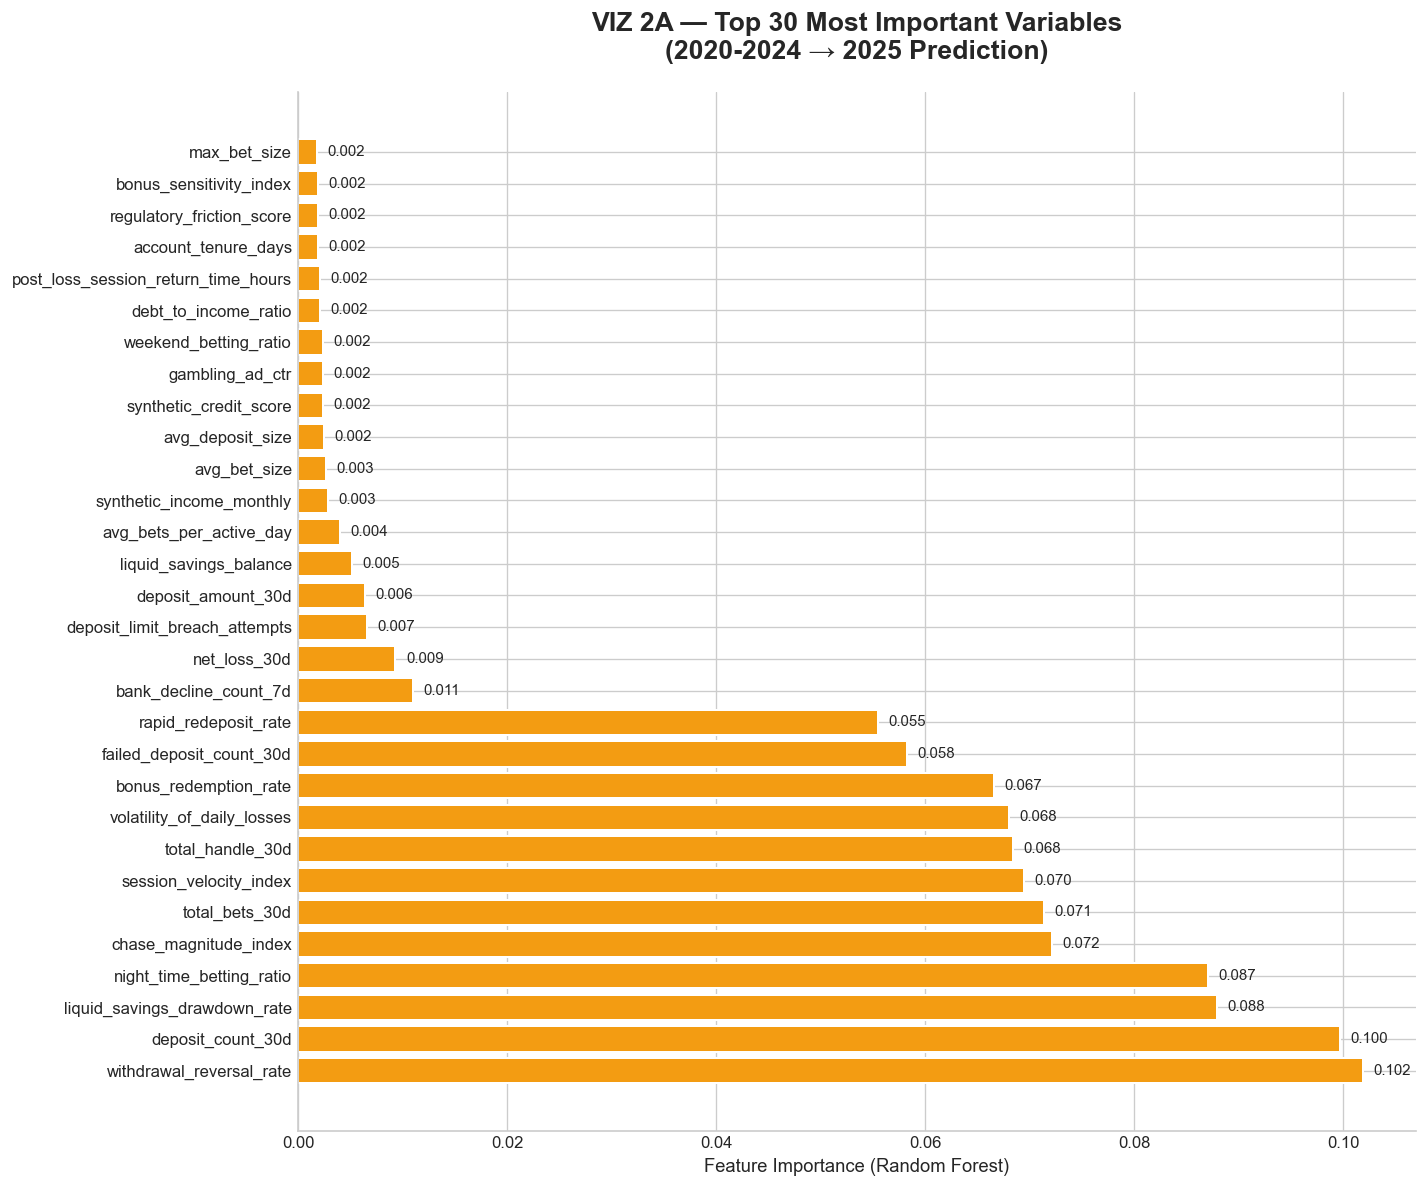

 VIZ 2A: Variable Importance saved

TOP 5 MOST IMPORTANT FEATURES:
['chase_magnitude_index', 'night_time_betting_ratio', 'liquid_savings_drawdown_rate', 'deposit_count_30d', 'withdrawal_reversal_rate']


In [23]:
#visuliaze variable importance 
# VIZ 2A: Variable Importance
importances = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True).tail(30)

plt.figure(figsize=(12, 10))
bars = plt.barh(range(len(importances)), importances['importance'], 
                color=COLORS[1], edgecolor='white', linewidth=1.2)
plt.yticks(range(len(importances)), importances['feature'])
plt.xlabel('Feature Importance (Random Forest)')
plt.title('VIZ 2A — Top 30 Most Important Variables\n(2020-2024 → 2025 Prediction)', 
          fontsize=16, fontweight='bold', pad=20)

# Add value labels
for i, (idx, row) in enumerate(importances.iterrows()):
    plt.text(row['importance'] + 0.001, i, f'{row["importance"]:.3f}', 
             va='center', fontsize=9)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "VIZ_2A_variable_importance.png", dpi=300, bbox_inches='tight')
plt.show()
print(" VIZ 2A: Variable Importance saved")
print("\nTOP 5 MOST IMPORTANT FEATURES:")
print(importances.tail().feature.tolist())

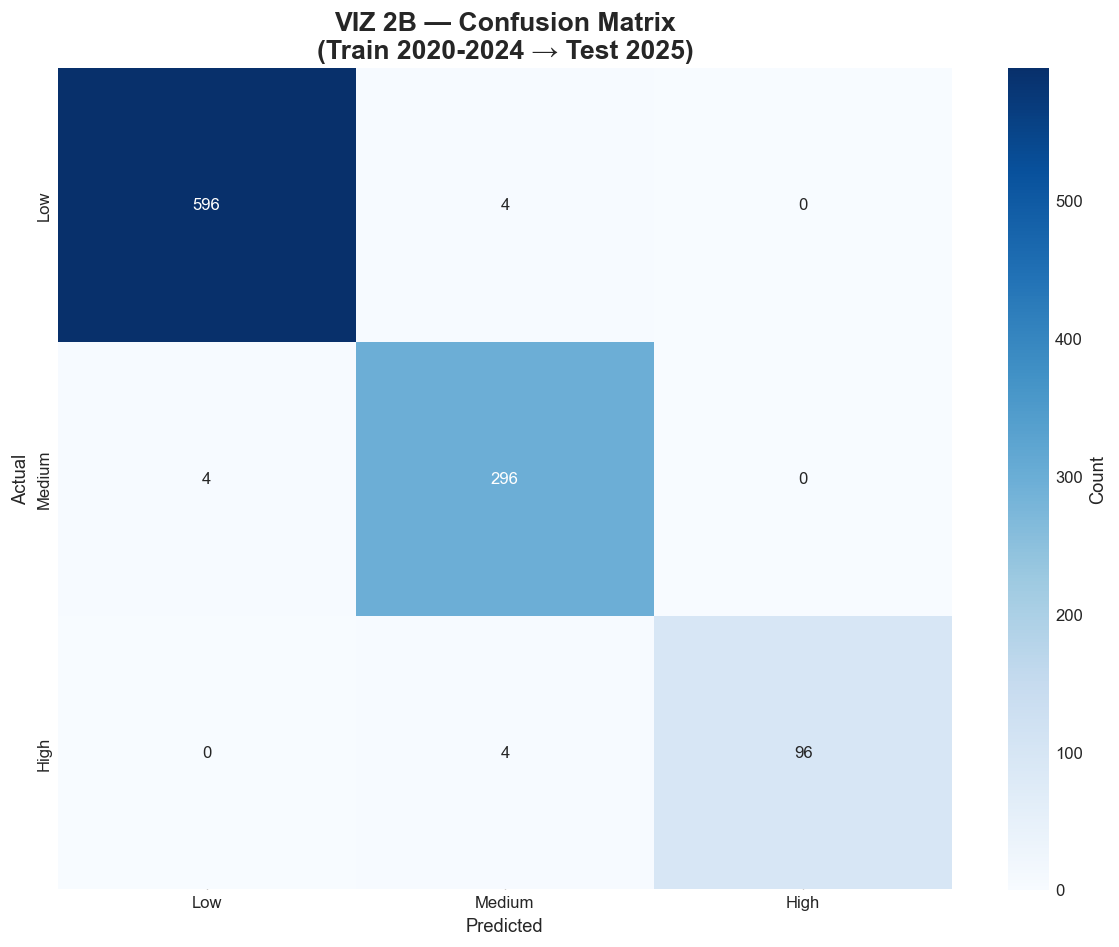

 VIZ 2B: Confusion Matrix saved


In [24]:
# VIZ 2B: Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[LABEL_MAP[i] for i in range(3)],
            yticklabels=[LABEL_MAP[i] for i in range(3)],
            cbar_kws={'label': 'Count'})
plt.title('VIZ 2B — Confusion Matrix\n(Train 2020-2024 → Test 2025)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "VIZ_2B_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()
print(" VIZ 2B: Confusion Matrix saved")

In [30]:

from pathlib import Path
import pip
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

%pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                            accuracy_score, precision_recall_fscore_support)
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Setup
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

# Assuming you have: X_train, X_test, y_train, y_test from previous pipeline
# And FEATURES, LABEL_MAP, COLORS defined

LABEL_MAP = {0: "Low", 1: "Medium", 2: "High"}
COLORS = ["#2ecc71", "#f39c12", "#e74c3c"]

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/tsing/Library/Python/3.9/lib/python/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <89AD948E-E564-3266-867D-7AF89D6488F0> /Users/tsing/Library/Python/3.9/lib/python/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (n